# CNN + LSTM for emg2pose

Train CNN+LSTM and CNN-only models to predict hand joint angles from EMG signals

**Steps:**
1. Setup: mount drive, set paths
2. Configure training parameters
3. Load data with Welford normalization
4. Build model, train, evaluate
5. Visualize results

In [1]:
from google.colab import drive
from pathlib import Path
drive.mount('/content/drive', force_remount=True)

# Check that the shared drive folder is accessible
!ls "/content/drive/Shareddrives/EMG POSE deep learning/CNN_LSTM/"

Mounted at /content/drive
CNN_diagnostics.ipynb	  load_data_local.py	   model.py	welford.py
CNN_generalization.ipynb  load_data.py		   outputs
CNN_LSTM.ipynb		  meta_subset_12users.csv  __pycache__
data			  meta_subset.csv	   train.py


## 1. Setup

In [2]:
import os
import pandas as pd

REPO_DIR = "/content/drive/Shareddrives/EMG POSE deep learning/CNN_LSTM/"
os.chdir(REPO_DIR)
print(f"Working directory: {os.getcwd()}")

Working directory: /content/drive/Shareddrives/EMG POSE deep learning/CNN_LSTM


In [3]:
# Point to the shared data folder
DATA_DIR = "/content/drive/Shareddrives/EMG POSE deep learning/data/data_subset"
assert os.path.exists(DATA_DIR), "Data not found!"

n_files = len([f for f in os.listdir(DATA_DIR) if f.endswith('.hdf5')])
print(f"HDF5 files: {n_files}")

HDF5 files: 1888


In [4]:
# Build metadata subset -- match the 10-user cohort
# Must match the same 10 users used by LSTM and TDS_LSTM pipelines
COHORT = [
    "8e69533c16", "3976352430", "2942949786", "1896997952", "0625995630",
    "2668760727", "3589743749", "2251681168", "2af4aec870", "7e08fa55fd",
]

meta = pd.read_csv(os.path.join(DATA_DIR, "metadata.csv"))
meta_subset = meta[meta['user'].isin(COHORT)].copy()
meta_subset.to_csv(os.path.join(REPO_DIR, "meta_subset.csv"), index=False)

print(f"Matched {len(meta_subset)} sessions from {meta_subset['user'].nunique()} users")
print(meta_subset['split'].value_counts().sort_index())

Matched 1584 sessions from 10 users
split
test     323
train    953
val      308
Name: count, dtype: int64


## 2. Import from repo modules

In [5]:
import torch
from pathlib import Path

# Import from the .py files in this folder
# from load_data import get_dataloaders, BATCH_SIZE
from load_data_local import get_dataloaders, BATCH_SIZE
from model import CNNPoseLSTM, CNNPoseLSTM2d, CNNOnly
from train import (
    train_one_epoch, evaluate,
    save_history, save_model, plot_losses,
)
from welford import apply_welford_to_loaders

## 3. Configuration

**CNN+LSTM concept:** The Conv1d layer acts as a learned feature extractor
across the 16 EMG channels at each timestep -- similar to how CNNs extract
spatial features in images (see https://github.com/TheErdosInstitute/deep-learning/blob/main/07_cnns.ipynb). The LSTM then models temporal
dependencies across those extracted features.

In [6]:
# Which model to train: "cnn_lstm", "cnn_lstm_2d", or "cnn_only"
MODEL_TYPE = "cnn_lstm_2d"

# GPU configs
CONFIG = {
    # Data
    "data_dir": DATA_DIR,
    "test_mode": False,
    "use_test": True,
    "meta_dir": os.path.join(REPO_DIR, "meta_subset.csv"),

    # CNN args (shared by both models)
    "filters": 48,         # number of Conv output channels
    "kernel_size": 5,      # temporal kernel width

    # LSTM args (cnn_lstm / cnn_lstm_2d only)
    # v2: matched to LSTM-only Welford baseline
    "hidden_size": 256,
    "num_layers": 2,
    "dropout": 0.1,

    # Conv2d args (cnn_lstm_2d and cnn_only)
    "num_conv_layers": 3,  # stacked Conv2d layers
    "channel_kernel": 3,   # spatial kernel across electrode channels

    # Training
    "epochs": 50,
    "lr": 1e-4,
    "batch_size": 64,      # matched to LSTM-only
    "patience": 50,

    # Output -- conv2d gets its own directory to preserve the conv1d run
    "output_dir": os.path.join(REPO_DIR, "outputs", "cnn_lstm_v2_conv2d"),
}

print(f"\nModel: {MODEL_TYPE}")
print(f"Configuration:")
for k, v in CONFIG.items():
    print(f"  {k}: {v}")


Model: cnn_lstm_2d
Configuration:
  data_dir: /content/drive/Shareddrives/EMG POSE deep learning/data/data_subset
  test_mode: False
  use_test: True
  meta_dir: /content/drive/Shareddrives/EMG POSE deep learning/CNN_LSTM/meta_subset.csv
  filters: 48
  kernel_size: 5
  hidden_size: 256
  num_layers: 2
  dropout: 0.1
  num_conv_layers: 3
  channel_kernel: 3
  epochs: 50
  lr: 0.0001
  batch_size: 64
  patience: 50
  output_dir: /content/drive/Shareddrives/EMG POSE deep learning/CNN_LSTM/outputs/cnn_lstm_v2_conv2d


In [7]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}\n")

# --- Data ---
loaders = get_dataloaders(
    data_dir=CONFIG["data_dir"],
    metadata=CONFIG["meta_dir"],
    test_mode=CONFIG["test_mode"],
    batch_size=CONFIG["batch_size"],
    use_test=CONFIG["use_test"],
    zscore=False,
)

print(f"\n{'Split':<8} {'Batches':>8} {'Samples':>10}")
for name, loader in loaders.items():
    print(f"{name:<8} {len(loader):>8} {len(loader.dataset):>10}")

# --- Inspect a batch ---
batch = next(iter(loaders["train"]))
print(f"\nBatch shapes:")
for key, val in batch.items():
    if isinstance(val, torch.Tensor):
        print(f"  {key:<20} {str(val.shape):<25} dtype={val.dtype}")

# Apply Welford per-window normalization
apply_welford_to_loaders(loaders)

Using device: cuda

=== Loading data from /content/drive/Shareddrives/EMG POSE deep learning/data/data_subset ===
    Metadata: /content/drive/Shareddrives/EMG POSE deep learning/CNN_LSTM/meta_subset.csv


Using splits: train=953, val=308, test=323
  Local staging: copying 1584 files to /content/data_local ...
    100/1584 copied ...
    200/1584 copied ...
    300/1584 copied ...
    400/1584 copied ...
    500/1584 copied ...
    600/1584 copied ...
    700/1584 copied ...
    800/1584 copied ...
    900/1584 copied ...
    1000/1584 copied ...
    1100/1584 copied ...
    1200/1584 copied ...
    1300/1584 copied ...
    1400/1584 copied ...
    1500/1584 copied ...
  Local staging: copied 1584 files in 878.0s
  DataLoader: pin_memory=True, num_workers=4, prefetch_factor=2

Split     Batches    Samples
train          63       4054
val            23       1446
test           39       2452

Batch shapes:
  emg                  torch.Size([64, 16, 11790]) dtype=torch.float32
  joint_an

In [8]:
# Sanity check: after Welford, EMG should be ~mean=0, std=1
batch = next(iter(loaders["train"]))
emg = batch["emg"]  # (B, 16, T)
print(f"EMG mean: {emg.mean():.4f}  (should be ~0)")
print(f"EMG std:  {emg.std():.4f}   (should be ~1)")

EMG mean: -0.0000  (should be ~0)
EMG std:  1.0000   (should be ~1)


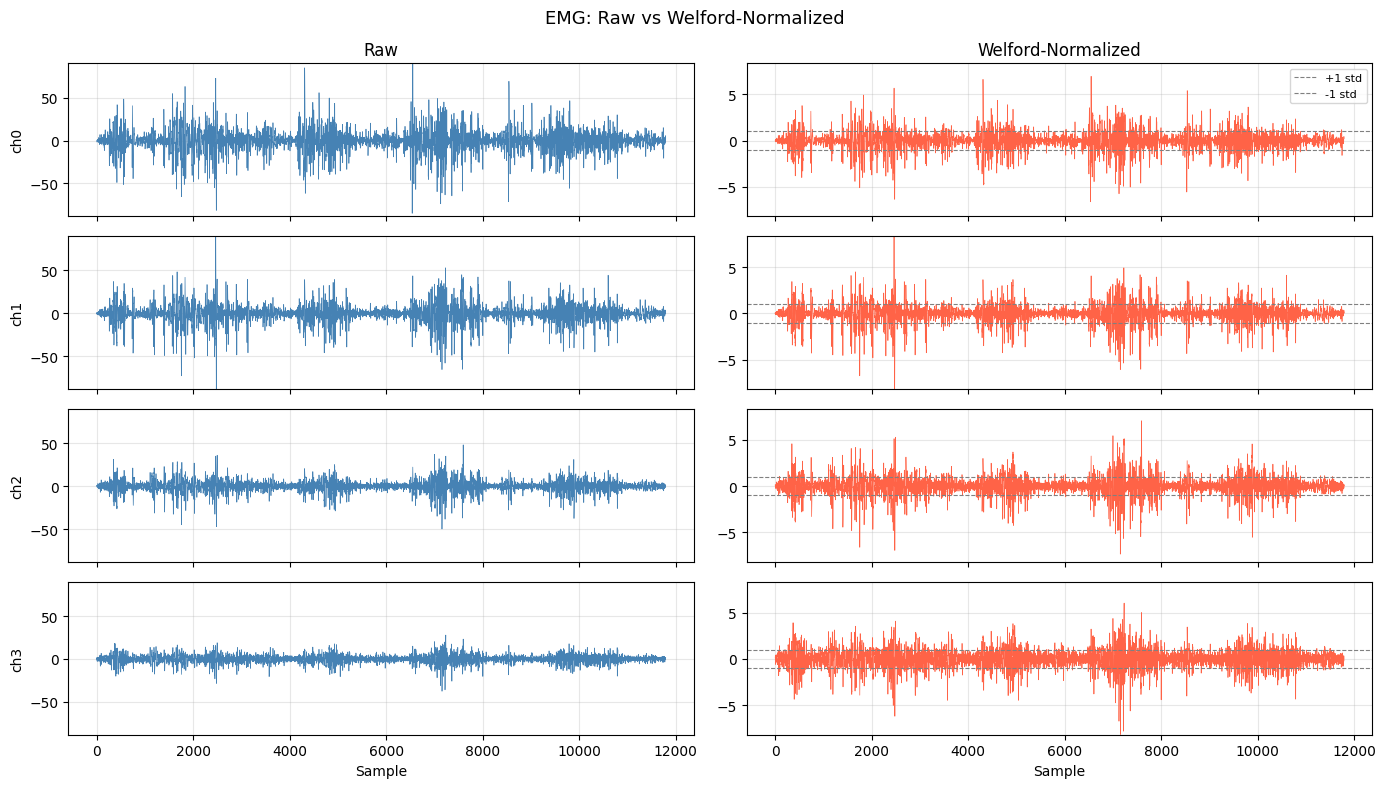

Raw        -- mean: 0.0002  std: 19.6392
Normalized -- mean: -0.0000  std: 1.0000


In [9]:
# Welford normalization visualization
# Shows raw vs normalized EMG for a few channels

import matplotlib.pyplot as plt
import h5py
from welford import WELFORD_NORMALIZER

plot_dataset = loaders["train"].dataset.datasets[0]

# Read raw EMG directly from HDF5 to avoid Drive file handle issues
with h5py.File(plot_dataset.hdf5_path, 'r') as f:
    raw_emg = torch.tensor(f['emg2pose/timeseries']['emg'][:11790], dtype=torch.float32)  # (T, 16)

normalized_emg = WELFORD_NORMALIZER(raw_emg)  # (T, 16)

# Transpose to (16, T) for per-channel plotting
raw_emg = raw_emg.T
normalized_emg = normalized_emg.T

channels_to_plot = [0, 1, 2, 3]
time_axis = range(raw_emg.shape[1])

# Shared y-axis per column: all Raw channels share one range, all Normalized share another
fig, axes = plt.subplots(len(channels_to_plot), 2, figsize=(14, 8), sharex=True)
fig.suptitle("EMG: Raw vs Welford-Normalized", fontsize=13)

# Compute shared y-limits across the plotted channels
raw_vals = raw_emg[channels_to_plot].numpy()
norm_vals = normalized_emg[channels_to_plot].numpy()
raw_ylim = (raw_vals.min(), raw_vals.max())
norm_ylim = (norm_vals.min(), norm_vals.max())

for row, ch in enumerate(channels_to_plot):
    axes[row, 0].plot(time_axis, raw_emg[ch].numpy(), color="steelblue", linewidth=0.5)
    axes[row, 0].set_ylabel(f"ch{ch}")
    axes[row, 0].set_ylim(raw_ylim)
    axes[row, 0].grid(True, alpha=0.3)
    if row == 0:
        axes[row, 0].set_title("Raw")

    axes[row, 1].plot(time_axis, normalized_emg[ch].numpy(), color="tomato", linewidth=0.5)
    axes[row, 1].axhline(y=1, color="gray", linestyle="--", linewidth=0.8, label="+1 std" if row == 0 else None)
    axes[row, 1].axhline(y=-1, color="gray", linestyle="--", linewidth=0.8, label="-1 std" if row == 0 else None)
    axes[row, 1].set_ylim(norm_ylim)
    axes[row, 1].grid(True, alpha=0.3)
    if row == 0:
        axes[row, 1].set_title("Welford-Normalized")
        axes[row, 1].legend(loc="upper right", fontsize=8)

axes[-1, 0].set_xlabel("Sample")
axes[-1, 1].set_xlabel("Sample")
fig.tight_layout()
plt.show()

print(f"Raw        -- mean: {raw_emg.mean():.4f}  std: {raw_emg.std():.4f}")
print(f"Normalized -- mean: {normalized_emg.mean():.4f}  std: {normalized_emg.std():.4f}")

In [10]:
# --- Build Model ---
if MODEL_TYPE == "cnn_lstm":
    model = CNNPoseLSTM(
        hidden_size=CONFIG["hidden_size"],
        num_layers=CONFIG["num_layers"],
        dropout=CONFIG["dropout"],
        filters=CONFIG["filters"],
        kernel_size=CONFIG["kernel_size"],
    ).to(device)
    model_name = "CNN+LSTM"
elif MODEL_TYPE == "cnn_lstm_2d":
    model = CNNPoseLSTM2d(
        hidden_size=CONFIG["hidden_size"],
        num_layers=CONFIG["num_layers"],
        dropout=CONFIG["dropout"],
        filters=CONFIG["filters"],
        kernel_size=CONFIG["kernel_size"],
        num_conv_layers=CONFIG["num_conv_layers"],
        channel_kernel=CONFIG["channel_kernel"],
    ).to(device)
    model_name = "CNN+LSTM (Conv2d)"
else:
    model = CNNOnly(
        filters=CONFIG["filters"],
        kernel_size=CONFIG["kernel_size"],
        num_conv_layers=CONFIG["num_conv_layers"],
        channel_kernel=CONFIG["channel_kernel"],
    ).to(device)
    model_name = "CNN-only"

n_params = sum(p.numel() for p in model.parameters())
print(f"Model: {model_name} ({n_params:,} parameters)")
if MODEL_TYPE in ("cnn_lstm", "cnn_lstm_2d"):
    print(f"  hidden_size={CONFIG['hidden_size']}, num_layers={CONFIG['num_layers']}")
    print(f"  filters={CONFIG['filters']}, kernel_size={CONFIG['kernel_size']}")
    if MODEL_TYPE == "cnn_lstm_2d":
        print(f"  num_conv_layers={CONFIG['num_conv_layers']}, channel_kernel={CONFIG['channel_kernel']}")
else:
    print(f"  filters={CONFIG['filters']}, kernel_size={CONFIG['kernel_size']}, channel_kernel={CONFIG['channel_kernel']}")
    print(f"  num_conv_layers={CONFIG['num_conv_layers']}")

# --- Optimizer + Scheduler ---
optimizer = torch.optim.Adam(model.parameters(), lr=CONFIG["lr"])

# Halves learning rate when val loss plateaus for 3 epochs
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode="min", factor=0.5, patience=3,
)

# --- Output dir ---
output_dir = Path(CONFIG["output_dir"])
output_dir.mkdir(parents=True, exist_ok=True)

Model: CNN+LSTM (Conv2d) (915,092 parameters)
  hidden_size=256, num_layers=2
  filters=48, kernel_size=5
  num_conv_layers=3, channel_kernel=3


## 5. Train

In [11]:
import time

best_loss = float("inf")
epochs_without_improvement = 0
use_test = CONFIG["use_test"] and "test" in loaders
patience = CONFIG["patience"]
max_epochs = CONFIG["epochs"]

history = {"train_loss": [], "val_loss": [], "lr": []}
if use_test:
    history["test_loss"] = []

print(f"Training {model_name} for up to {max_epochs} epochs (patience={patience})")
print(f"  Checkpoint metric: val_loss")
print()

try:
    for epoch in range(1, max_epochs + 1):
        start_time = time.perf_counter()

        train_loss = train_one_epoch(model, loaders["train"], optimizer, device)
        val_loss = evaluate(model, loaders["val"], device)
        current_lr = optimizer.param_groups[0]["lr"]

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["lr"].append(current_lr)

        # Step the scheduler on val loss
        scheduler.step(val_loss)

        # Checkpoint on val loss improvement
        improved = ""
        if val_loss < best_loss:
            best_loss = val_loss
            epochs_without_improvement = 0
            save_model(model, optimizer, epoch, best_loss,
                       save_path=output_dir / "best_model.pt")
            improved = " *"
        else:
            epochs_without_improvement += 1

        if use_test:
            test_loss = evaluate(model, loaders["test"], device)
            history["test_loss"].append(test_loss)

        elapsed = time.perf_counter() - start_time

        log = f"Epoch {epoch:3d}/{max_epochs}  train={train_loss:.4f}  val={val_loss:.4f}"
        if use_test:
            log += f"  test={test_loss:.4f}"
        log += f"  lr={current_lr:.2e}  ({elapsed:.1f}s){improved}"
        print(log)

        if epochs_without_improvement >= patience:
            print(f"\nEarly stopping at epoch {epoch} (no improvement for {patience} epochs)")
            break

finally:
    # Save history even if training crashes partway through
    if history["train_loss"]:
        save_history(history, save_path=output_dir / "loss_history.json")

Training CNN+LSTM (Conv2d) for up to 50 epochs (patience=50)
  Checkpoint metric: val_loss

Saved model checkpoint to /content/drive/Shareddrives/EMG POSE deep learning/CNN_LSTM/outputs/cnn_lstm_v2_conv2d/best_model.pt (epoch 1)
Epoch   1/50  train=0.3501  val=0.3000  test=0.3186  lr=1.00e-04  (54.2s) *
Saved model checkpoint to /content/drive/Shareddrives/EMG POSE deep learning/CNN_LSTM/outputs/cnn_lstm_v2_conv2d/best_model.pt (epoch 2)
Epoch   2/50  train=0.2942  val=0.2968  test=0.3174  lr=1.00e-04  (52.1s) *
Epoch   3/50  train=0.2924  val=0.2985  test=0.3179  lr=1.00e-04  (52.1s)
Saved model checkpoint to /content/drive/Shareddrives/EMG POSE deep learning/CNN_LSTM/outputs/cnn_lstm_v2_conv2d/best_model.pt (epoch 4)
Epoch   4/50  train=0.2912  val=0.2931  test=0.3177  lr=1.00e-04  (52.3s) *
Epoch   5/50  train=0.2906  val=0.2948  test=0.3157  lr=1.00e-04  (52.3s)
Epoch   6/50  train=0.2889  val=0.2949  test=0.3216  lr=1.00e-04  (52.1s)
Epoch   7/50  train=0.2887  val=0.2954  test=0.

## 6. Visualize & eval

In [12]:
# Plot training curves
plot_losses(history, save_path=output_dir / "training_curves.png")

Saved training curves to /content/drive/Shareddrives/EMG POSE deep learning/CNN_LSTM/outputs/cnn_lstm_v2_conv2d/training_curves.png


In [13]:
import numpy as np

# Load best model and evaluate
print(f"Best val_loss: {best_loss:.4f} rad  ({np.rad2deg(best_loss):.2f}°)")

best_ckpt = output_dir / "best_model.pt"
if best_ckpt.exists():
    checkpoint = torch.load(best_ckpt, map_location=device, weights_only=True)
    model.load_state_dict(checkpoint["model_state_dict"])
    print(f"Loaded best model from epoch {checkpoint['epoch']}")

val_mae = evaluate(model, loaders["val"], device)
print(f"Val MAE: {val_mae:.4f} rad  ({np.rad2deg(val_mae):.2f}°)")

if use_test:
    test_mae = evaluate(model, loaders["test"], device)
    print(f"Test MAE: {test_mae:.4f} rad  ({np.rad2deg(test_mae):.2f}°)")

Best val_loss: 0.2818 rad  (16.15°)
Loaded best model from epoch 50
Val MAE: 0.2818 rad  (16.15°)
Test MAE: 0.3120 rad  (17.88°)


In [14]:
# Download outputs from Colab (uncomment to use)

# from google.colab import files
# files.download(str(output_dir / "best_model.pt"))
# files.download(str(output_dir / "loss_history.json"))
# files.download(str(output_dir / "training_curves.png"))

## 7. CNN only vs. CNN + LSTM

Load saved results from all CNN runs and compare side by side.
v1 used a smaller LSTM (h=128, L=1); v2 matches the LSTM-only Welford baseline (h=256, L=2).

In [15]:
import json
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# Load saved loss histories from all available runs
output_root = Path(REPO_DIR) / "outputs"
histories = {}
for name in ["cnn_lstm", "cnn_lstm_v2", "cnn_only"]:
    history_path = output_root / name / "loss_history.json"
    if history_path.exists():
        with open(history_path) as f:
            histories[name] = json.load(f)
        print(f"Loaded {name}")
    else:
        print(f"Skipped {name} (not yet run)")

Loaded cnn_lstm
Loaded cnn_lstm_v2
Loaded cnn_only


### Training curves                                                           

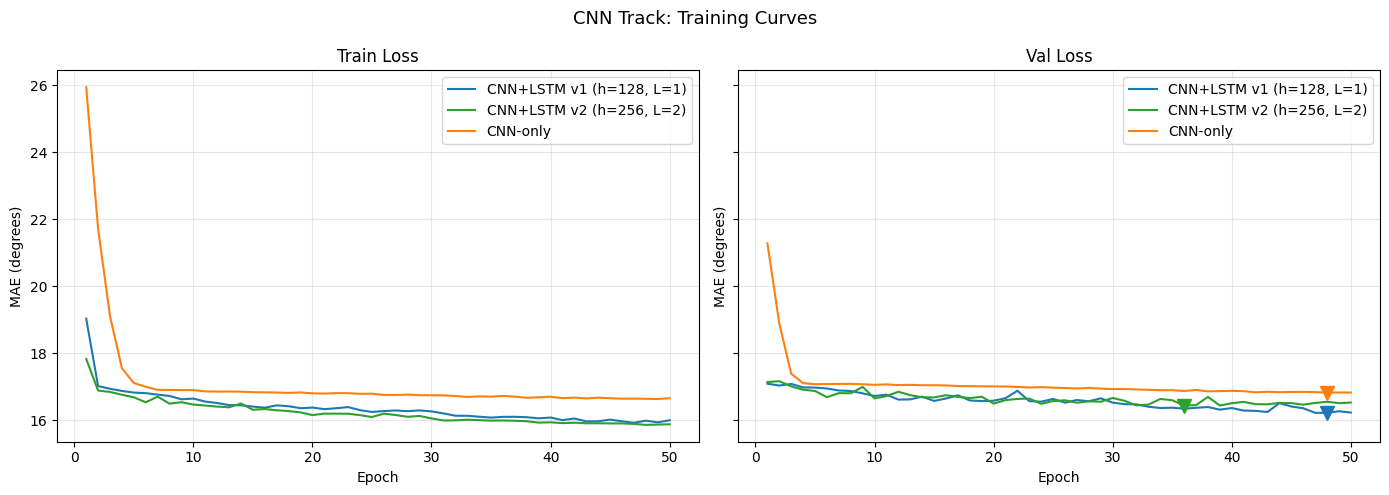

In [16]:
# Training curves (train left, val right)
# Triangle markers show best val epoch

LABELS = {
    "cnn_lstm": ("CNN+LSTM v1 (h=128, L=1)", "tab:blue"),
    "cnn_lstm_v2": ("CNN+LSTM v2 (h=256, L=2)", "tab:green"),
    "cnn_only": ("CNN-only", "tab:orange"),
}

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

for ax, split, title in [
    (axes[0], "train_loss", "Train Loss"),
    (axes[1], "val_loss", "Val Loss"),
]:
    for name in histories:
        label, color = LABELS[name]
        epochs = range(1, len(histories[name][split]) + 1)
        vals_deg = np.rad2deg(histories[name][split])
        ax.plot(epochs, vals_deg, color=color, label=label)

        if split == "val_loss":
            best_idx = int(np.argmin(histories[name][split]))
            ax.plot(best_idx + 1, vals_deg[best_idx], "v",
                    color=color, markersize=10)

    ax.set_xlabel("Epoch")
    ax.set_ylabel("MAE (degrees)")
    ax.set_title(title)
    ax.legend()
    ax.grid(True, alpha=0.3)

fig.suptitle("CNN Track: Training Curves", fontsize=13)
fig.tight_layout()
plt.show()

In [17]:
# Summary table
rows = []
for name in histories:
    label, _ = LABELS[name]
    best_idx = int(np.argmin(histories[name]["val_loss"]))
    rows.append({
        "Model": label,
        "Best Epoch": best_idx + 1,
        "Train MAE":
f"{np.rad2deg(histories[name]['train_loss'][best_idx]):.2f}°",
        "Val MAE":
f"{np.rad2deg(histories[name]['val_loss'][best_idx]):.2f}°",
        "Test MAE":
f"{np.rad2deg(histories[name]['test_loss'][best_idx]):.2f}°",
    })

display(pd.DataFrame(rows))


,Model,Best Epoch,Train MAE,Val MAE,Test MAE
0,"CNN+LSTM v1 (h=128, L=1)",48,15.99°,16.22°,17.82°
1,"CNN+LSTM v2 (h=256, L=2)",36,15.99°,16.44°,17.71°
2,CNN-only,48,16.64°,16.83°,18.13°


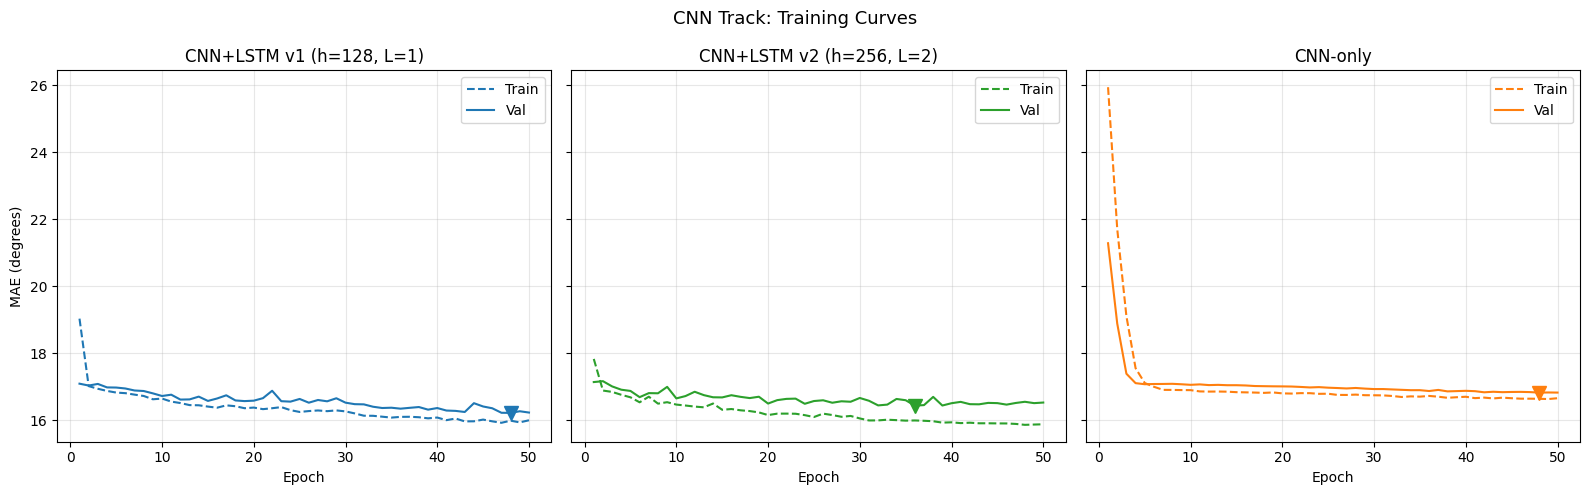

In [18]:
  # One subplot per model (train vs val in each)
  # Triangle markers show best val epoch

  LABELS = {
      "cnn_lstm": ("CNN+LSTM v1 (h=128, L=1)", "tab:blue"),
      "cnn_lstm_v2": ("CNN+LSTM v2 (h=256, L=2)", "tab:green"),
      "cnn_only": ("CNN-only", "tab:orange"),
  }

  fig, axes = plt.subplots(1, 3, figsize=(16, 5), sharey=True)

  for ax, name in zip(axes, histories):
      label, color = LABELS[name]
      epochs = range(1, len(histories[name]["train_loss"]) + 1)
      train_deg = np.rad2deg(histories[name]["train_loss"])
      val_deg = np.rad2deg(histories[name]["val_loss"])

      ax.plot(epochs, train_deg, color=color, linestyle="--", label="Train")
      ax.plot(epochs, val_deg, color=color, linestyle="-", label="Val")

      # Best val epoch
      best_idx = int(np.argmin(histories[name]["val_loss"]))
      ax.plot(best_idx + 1, val_deg[best_idx], "v",
              color=color, markersize=10)

      ax.set_xlabel("Epoch")
      ax.set_title(label)
      ax.legend()
      ax.grid(True, alpha=0.3)

  axes[0].set_ylabel("MAE (degrees)")
  fig.suptitle("CNN Track: Training Curves", fontsize=13)
  fig.tight_layout()
  plt.show()

### Learning rate schedule

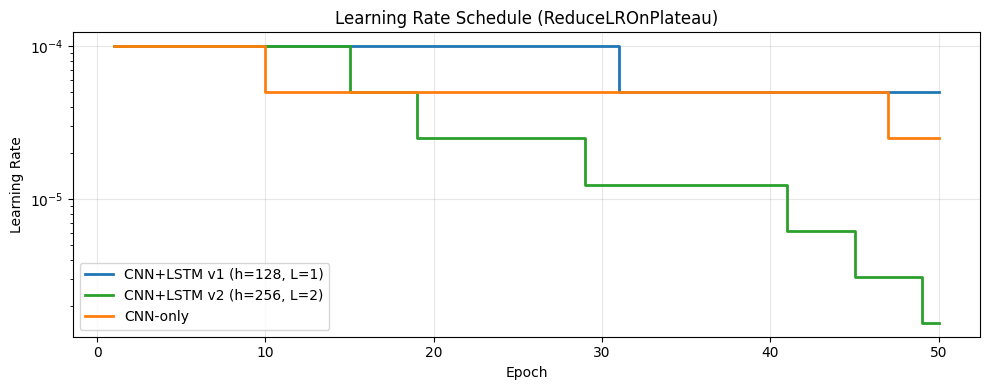

In [19]:
# Learning rate schedule
# All models use ReduceLROnPlateau (factor=0.5, patience=3)
# Each step down = val loss stopped improving for 3 epochs

fig, ax = plt.subplots(figsize=(10, 4))

for name in histories:
    label, color = LABELS[name]
    epochs = range(1, len(histories[name]["lr"]) + 1)
    ax.plot(epochs, histories[name]["lr"],
            color=color, label=label, linewidth=2, drawstyle="steps-post")

ax.set_xlabel("Epoch")
ax.set_ylabel("Learning Rate")
ax.set_yscale("log")
ax.set_title("Learning Rate Schedule (ReduceLROnPlateau)")
ax.legend()
ax.grid(True, alpha=0.3)
fig.tight_layout()
plt.show()

### Test loss

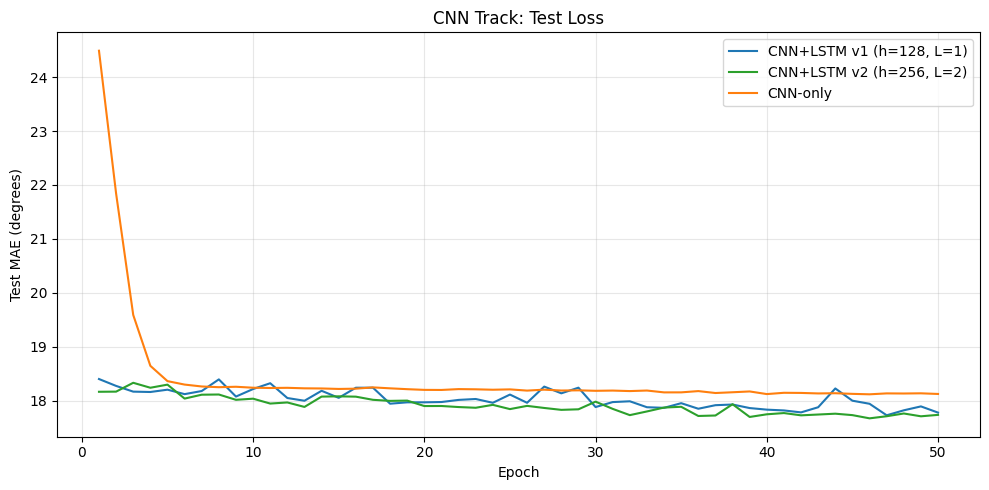

In [20]:
# Test loss over time
fig, ax = plt.subplots(figsize=(10, 5))

for name in histories:
    if "test_loss" not in histories[name]:
        continue
    label, color = LABELS[name]
    epochs = range(1, len(histories[name]["test_loss"]) + 1)
    ax.plot(epochs, np.rad2deg(histories[name]["test_loss"]),
            color=color, label=label)

ax.set_xlabel("Epoch")
ax.set_ylabel("Test MAE (degrees)")
ax.set_title("CNN Track: Test Loss")
ax.legend()
ax.grid(True, alpha=0.3)
fig.tight_layout()
plt.show()

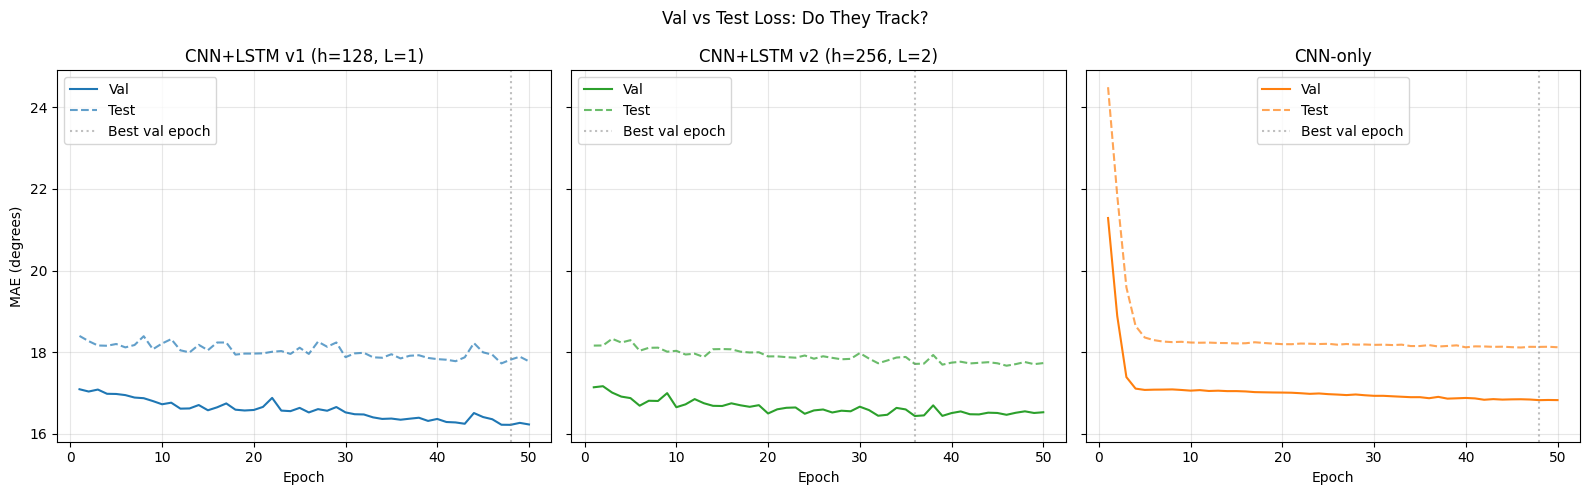

In [21]:
# Val vs test on same axes per model
# If the curves track each other, the model generalizes well
# If test diverges upward from val, the model may be overfitting to val

fig, axes = plt.subplots(1, 3, figsize=(16, 5), sharey=True)

for ax, name in zip(axes, histories):
    label, color = LABELS[name]
    epochs = range(1, len(histories[name]["val_loss"]) + 1)
    val_deg = np.rad2deg(histories[name]["val_loss"])
    test_deg = np.rad2deg(histories[name]["test_loss"])

    ax.plot(epochs, val_deg, color=color, label="Val")
    ax.plot(epochs, test_deg, color=color, linestyle="--", alpha=0.7,
label="Test")

    best_idx = int(np.argmin(histories[name]["val_loss"]))
    ax.axvline(best_idx + 1, color="gray", linestyle=":", alpha=0.5,
label="Best val epoch")

    ax.set_title(label)
    ax.set_xlabel("Epoch")
    ax.legend()
    ax.grid(True, alpha=0.3)

axes[0].set_ylabel("MAE (degrees)")
fig.suptitle("Val vs Test Loss: Do They Track?")
fig.tight_layout()
plt.show()

In [22]:
# Best test MAE per model
rows = []
for name in histories:
    if "test_loss" not in histories[name]:
        continue
    label, _ = LABELS[name]
    best_idx = int(np.argmin(histories[name]["test_loss"]))
    rows.append({
        "Model": label,
        "Best Test Epoch": best_idx + 1,
        "Test MAE":
f"{np.rad2deg(histories[name]['test_loss'][best_idx]):.2f}°",
    })

display(pd.DataFrame(rows))

,Model,Best Test Epoch,Test MAE
0,"CNN+LSTM v1 (h=128, L=1)",47,17.73°
1,"CNN+LSTM v2 (h=256, L=2)",46,17.67°
2,CNN-only,46,18.12°


## Summary

In [23]:
# Summary table
PARAMS = {
    "cnn_lstm": ("CNN+LSTM v1", "97,700", 128, 1),
    "cnn_lstm_v2": ("CNN+LSTM v2", "TBD", 256, 2),  # param count updates after first run
    "cnn_only": ("CNN-only", "28,292", "—", "—"),
}

rows = []
for name in histories:
    label, params, hidden, layers = PARAMS[name]
    h = histories[name]
    best_epoch = int(np.argmin(h["val_loss"])) + 1  # 1-indexed
    best_val = h["val_loss"][best_epoch - 1]
    best_test = h["test_loss"][best_epoch - 1] if "test_loss" in h else None
    best_train = h["train_loss"][best_epoch - 1]
    lr_at_best = h["lr"][best_epoch - 1]

    lr_drops = sum(
        1 for i in range(1, len(h["lr"]))
        if h["lr"][i] < h["lr"][i - 1]
    )

    row = {
        "Model": label,
        "Params": params,
        "LSTM hidden": hidden,
        "LSTM layers": layers,
        "Best Epoch": best_epoch,
        "Train MAE (°)": round(np.rad2deg(best_train), 2),
        "Val MAE (°)": round(np.rad2deg(best_val), 2),
        "LR Drops": lr_drops,
    }
    if best_test is not None:
        row["Test MAE (°)"] = round(np.rad2deg(best_test), 2)
    rows.append(row)

df = pd.DataFrame(rows)
df

,Model,Params,LSTM hidden,LSTM layers,Best Epoch,Train MAE (°),Val MAE (°),LR Drops,Test MAE (°)
0,CNN+LSTM v1,"97,700",128,1,48,15.99,16.22,1,17.82
1,CNN+LSTM v2,TBD,256,2,36,15.99,16.44,6,17.71
2,CNN-only,"28,292",—,—,48,16.64,16.83,2,18.13


In [24]:
# Sync Drive writes and release GPU runtime to stop billing
from google.colab import drive, runtime
try:
    print("Flushing Drive writes...")
    drive.flush_and_unmount()
    print("Drive synced and unmounted.")
except Exception as e:
    print(f"Drive flush failed: {e} -- releasing GPU anyway")
finally:
    print("Releasing GPU runtime...")
    runtime.unassign()

Flushing Drive writes...
Drive synced and unmounted.
Releasing GPU runtime...
